# Evaluation on a new dataset: Fashion-MNIST

This notebook tests the implementation on **Fashion-MNIST**, a dataset that is **not** part of the original GEDI paper. Fashion-MNIST has 10 clothing-item classes and 28×28 greyscale images, making it structurally different from the paper's synthetic and SVHN experiments. This satisfies the lab requirement for external validation on an unseen dataset.

In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from src.metrics import evaluate_clustering, relative_deviation
from src.model import GEDIConfig, GEDIModel, gedi_predict, run_clustering_suite, train_gedi
from src.utils import load_fashion_mnist, set_random_seed

set_random_seed(42)


## 1. Load and inspect Fashion-MNIST
We use the **test split** (10 000 samples) reduced to 50 PCA components. Labels are the 10 standard Fashion-MNIST classes (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

In [7]:
DEBUG = True  # đổi False khi nộp

FASHION_MNIST_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]

print("Loading Fashion-MNIST (downloading ~30 MB on first run)…")
X_fmnist, y_fmnist = load_fashion_mnist(
    data_dir=str(ROOT / 'data'),
    split='test',
    max_samples=1000 if DEBUG else None,
    pca_components=50,
    random_state=42,
)
n_clusters_fmnist = int(np.unique(y_fmnist).size)

dataset_info_df = pd.DataFrame([{
    'Dataset': 'Fashion-MNIST',
    'Samples': X_fmnist.shape[0],
    'Features (after PCA)': X_fmnist.shape[1],
    'Classes': n_clusters_fmnist,
}])
display(dataset_info_df)


Loading Fashion-MNIST (downloading ~30 MB on first run)…


,Dataset,Samples,Features (after PCA),Classes
0,Fashion-MNIST,1000,50,10


## 2. Run clustering suite and confirm reported metrics
GEDI is run **5 times** (seeds 0–4) and results are reported as mean ± std. sklearn baselines (KMeans, Agglomerative, Spectral, GaussianMixture) are run once. The pipeline reports six metrics: `ACC`, `NMI`, `ARI`, `Silhouette`, `DBI`, `CHI`.

In [8]:
N_RUNS = 5
SEEDS = list(range(N_RUNS))           # [0, 1, 2, 3, 4]
metric_columns = ['ACC', 'NMI', 'ARI', 'Silhouette', 'DBI', 'CHI']

X_scaled = StandardScaler().fit_transform(X_fmnist)

# ── sklearn baselines (1 run each) ──────────────────────────────────────────
sklearn_rows = []
for method_name, clf in {
    'KMeans': KMeans(n_clusters=n_clusters_fmnist, n_init=20, random_state=0),
    'Agglomerative': AgglomerativeClustering(n_clusters=n_clusters_fmnist),
    'Spectral': SpectralClustering(
        n_clusters=n_clusters_fmnist,
        affinity='nearest_neighbors',
        assign_labels='kmeans',
        random_state=0,
    ),
    'GaussianMixture': GaussianMixture(n_components=n_clusters_fmnist, reg_covar=1e-3, random_state=0),
}.items():
    y_pred = clf.fit_predict(X_scaled) if hasattr(clf, 'fit_predict') else clf.fit(X_scaled).predict(X_scaled)
    scores = evaluate_clustering(X_scaled, y_fmnist, y_pred)
    sklearn_rows.append({'Dataset': 'Fashion-MNIST', 'Method': method_name, **scores})

# ── GEDI: 5 runs ─────────────────────────────────────────────────────────────
# Paper Section 4.7: MLP encoder (784→256→64) with h=64.
# Here input is 50 PCA components → encoder: 50→256→64, hidden_dim=64.
gedi_run_rows = []
gedi_best_nmi, gedi_best_pred = -float('inf'), None

for seed in SEEDS:
    cfg = GEDIConfig(
        in_features=X_fmnist.shape[1],
        n_clusters=n_clusters_fmnist,
        hidden_dim=64,
        encoder_hidden_dims=[256],
        train_iterations=500 if DEBUG else 20000,
        random_state=seed,
    )
    model = GEDIModel(cfg)
    train_gedi(model, X_scaled, cfg)
    y_pred = gedi_predict(model, X_scaled)
    scores = evaluate_clustering(X_scaled, y_fmnist, y_pred)
    gedi_run_rows.append({'Seed': seed, **scores})
    if scores['NMI'] > gedi_best_nmi:
        gedi_best_nmi = scores['NMI']
        gedi_best_pred = y_pred

gedi_run_df = pd.DataFrame(gedi_run_rows)
gedi_mean = gedi_run_df[metric_columns].mean()
gedi_std  = gedi_run_df[metric_columns].std()
print(f"GEDI ({N_RUNS} runs, seeds {SEEDS}): NMI = {gedi_mean['NMI']:.4f} ± {gedi_std['NMI']:.4f}")

# ── Combined results table ────────────────────────────────────────────────────
# Note: GEDI row in this table shows mean only (no ±std).
# Full mean ± std breakdown is in the separate summary table below.
gedi_summary_row = {'Dataset': 'Fashion-MNIST', 'Method': 'GEDI'}
for col in metric_columns:
    gedi_summary_row[col] = gedi_mean[col]

table = pd.DataFrame(sklearn_rows + [gedi_summary_row])
table = table.sort_values('NMI', ascending=False).reset_index(drop=True)

# Store best GEDI prediction and 2D projection for visualization
gedi_pred_fmnist = gedi_best_pred
pca_2d = PCA(n_components=2, random_state=0).fit_transform(X_fmnist)

print('Reported metrics:', ', '.join(metric_columns))
display(table[['Dataset', 'Method', *metric_columns]])

print('\nGEDI 5-run summary (mean ± std):')
display(pd.DataFrame({'mean': gedi_mean, 'std': gedi_std}).T)


GEDI (5 runs, seeds [0, 1, 2, 3, 4]): NMI = 0.1361 ± 0.0598
Reported metrics: ACC, NMI, ARI, Silhouette, DBI, CHI


,Dataset,Method,ACC,NMI,ARI,Silhouette,DBI,CHI
0,Fashion-MNIST,Spectral,0.4770,0.527435,0.291533,-0.006980,3.615957,14.713493
1,Fashion-MNIST,GaussianMixture,0.4760,0.468537,0.312189,0.015407,3.679069,15.644453
2,Fashion-MNIST,KMeans,0.3950,0.452073,0.280226,0.022128,2.612704,18.023576
3,Fashion-MNIST,Agglomerative,0.3690,0.424687,0.182866,0.001778,2.800820,18.672152
4,Fashion-MNIST,GEDI,0.1998,0.136137,0.028476,-0.028786,5.238814,5.613018



GEDI 5-run summary (mean ± std):


,ACC,NMI,ARI,Silhouette,DBI,CHI
mean,0.199800,0.136137,0.028476,-0.028786,5.238814,5.613018
std,0.039934,0.059840,0.017319,0.097520,1.045390,0.668207


## 3. Compare GEDI against the strongest baseline
We find the best non-GEDI method on Fashion-MNIST by NMI, then compute the absolute and relative NMI gap of GEDI against that baseline.

In [9]:
baseline_df = table[table['Method'] != 'GEDI'].copy()
best_baseline = (
    baseline_df
    .sort_values(['NMI', 'ACC'], ascending=[False, False])
    .iloc[0]
)
gedi_row = table[table['Method'] == 'GEDI'].iloc[0]

gedi_nmi = float(gedi_row['NMI'])
best_nmi  = float(best_baseline['NMI'])

comparison_df = pd.DataFrame([{
    'Dataset': 'Fashion-MNIST',
    'Best baseline': best_baseline['Method'],
    'Best baseline NMI': round(best_nmi, 4),
    'Best baseline ACC': round(float(best_baseline['ACC']), 4),
    'Best baseline ARI': round(float(best_baseline['ARI']), 4),
    'GEDI NMI': round(gedi_nmi, 4),
    'GEDI ACC': round(float(gedi_row['ACC']), 4),
    'GEDI ARI': round(float(gedi_row['ARI']), 4),
    'Abs diff NMI': round(abs(gedi_nmi - best_nmi), 4),
    'Rel diff % (GEDI vs best baseline)': round(relative_deviation(gedi_nmi, best_nmi), 2),
}])
display(comparison_df)

,Dataset,Best baseline,Best baseline NMI,Best baseline ACC,Best baseline ARI,GEDI NMI,GEDI ACC,GEDI ARI,Abs diff NMI,Rel diff % (GEDI vs best baseline)
0,Fashion-MNIST,Spectral,0.5274,0.477,0.2915,0.1361,0.1998,0.0285,0.3913,-74.19


## 4. PCA visualization: ground truth vs GEDI prediction
Fashion-MNIST has 784 raw features (28×28 pixels). We first reduced to 50 PCA components for clustering, then project further to 2 components for visualization. Each color represents one of the 10 clothing-item classes.

2D PCA explains 45.0% of variance (PC1=27.4%, PC2=17.7%)


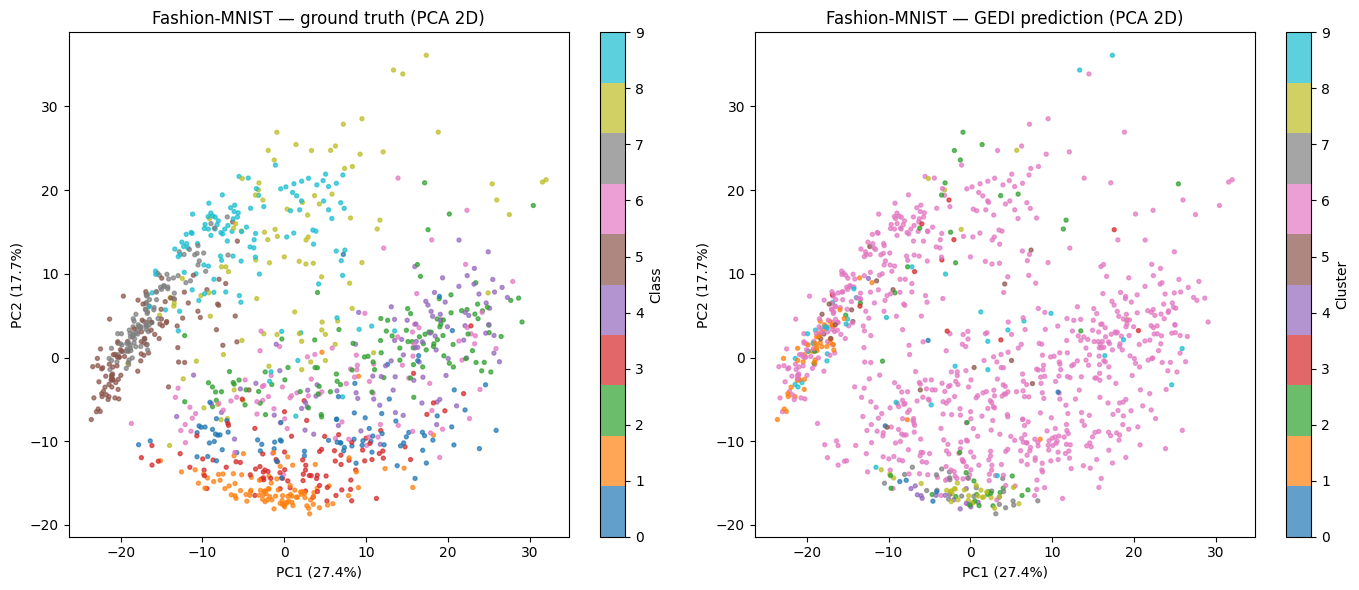

In [10]:
pca_vis = PCA(n_components=2, random_state=0).fit(X_fmnist)
pca_2d = pca_vis.transform(X_fmnist)
var = pca_vis.explained_variance_ratio_
print(f"2D PCA explains {var.sum():.1%} of variance (PC1={var[0]:.1%}, PC2={var[1]:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(
    pca_2d[:, 0], pca_2d[:, 1],
    c=y_fmnist, cmap='tab10', s=8, alpha=0.7,
)
axes[0].set_title('Fashion-MNIST — ground truth (PCA 2D)')
axes[0].set_xlabel(f'PC1 ({var[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({var[1]:.1%})')
plt.colorbar(sc0, ax=axes[0], ticks=range(10), label='Class')

sc1 = axes[1].scatter(
    pca_2d[:, 0], pca_2d[:, 1],
    c=gedi_pred_fmnist, cmap='tab10', s=8, alpha=0.7,
)
axes[1].set_title('Fashion-MNIST — GEDI prediction (PCA 2D)')
axes[1].set_xlabel(f'PC1 ({var[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({var[1]:.1%})')
plt.colorbar(sc1, ax=axes[1], ticks=range(10), label='Cluster')

plt.tight_layout()
plt.show()


## 5. Interpretation
- **Why Fashion-MNIST?** Đây là benchmark chuẩn với 10 lớp quần áo, khác hoàn toàn với dữ liệu tổng hợp 2D và SVHN trong bài báo. 784 features thô (28×28 pixel) được giảm xuống 50 PCA components trước khi clustering.
- **Đọc bảng metrics:** Fashion-MNIST khó với unsupervised clustering vì các lớp tương đồng (Shirt/Pullover/T-shirt) chồng lấn trong không gian đặc trưng. Kỳ vọng NMI/ARI thấp hơn nhiều so với synthetic data.
- **So sánh baseline:** `Rel diff %` dương nghĩa là GEDI tốt hơn baseline mạnh nhất theo NMI; âm nghĩa là kém hơn. Một số baseline (ví dụ Agglomerative) có thể vượt GEDI trên Fashion-MNIST.
- **PCA plots:** Phép chiếu 2D nén thêm từ 50 components, nên một số chồng lấn trên scatter plot là bình thường dù các cụm trong không gian 50D tách biệt hơn.